In [31]:
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from scipy.stats import skew
from sklearn.cluster import KMeans, kmeans_plusplus
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score


In [32]:
df = pd.read_csv('../data/raw/dataset-6ab989b678d90892980305.csv')

In [33]:
df_clean = df.copy()

In [34]:
# Drop the one null row from CREDIT_LIMIT

df_clean.dropna(subset=['CREDIT_LIMIT'], inplace=True)

In [35]:
df_clean.to_csv('../data/processed/card_profiler_clean.csv')

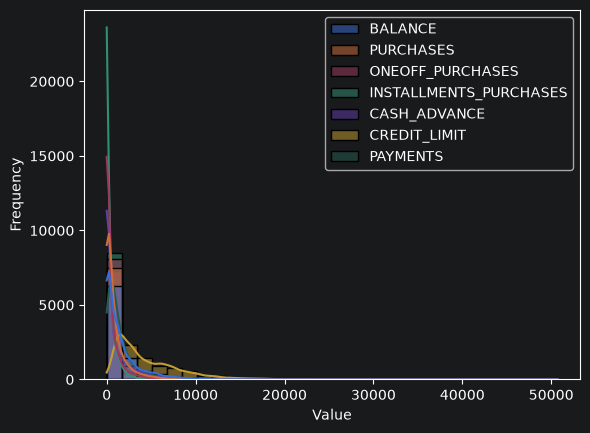

In [36]:
sns.histplot(df_clean, kde=True, color="crimson", bins=30)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [37]:
numeric_cols = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
                 "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

df_prepare_clustering = df_clean[numeric_cols].copy()

for i in numeric_cols:
    df_prepare_clustering[f"{i}_log"] = np.log1p(df[i])
    df_prepare_clustering.drop(columns=i, inplace=True)



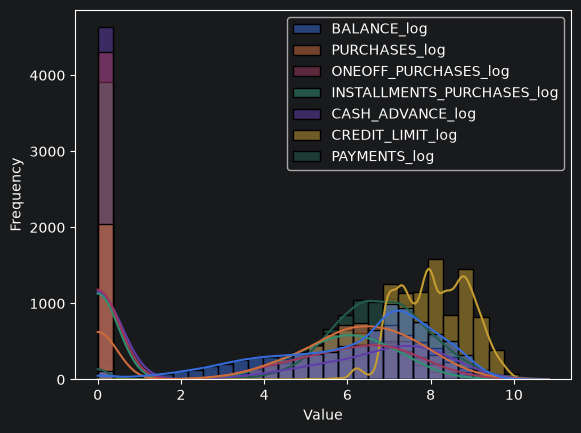

In [38]:

sns.histplot(df_prepare_clustering, kde=True, color="crimson", bins=30)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_prepare_clustering)

In [40]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

variance_per_pc = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_per_pc)

min_components = np.argmax(cumulative_variance > 0.80) + 1

print(min_components)



4


In [41]:
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)
variance_per_pc = pca.explained_variance_ratio_

for i, ratio in enumerate(variance_per_pc):
    print(f"PC{i+1} {ratio:.2%}")
print(f"{sum(variance_per_pc):.2%}")
df_prepare_clustering = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7'])
df_prepare_clustering.head()

PC1 35.36%
PC2 29.26%
PC3 11.40%
PC4 10.01%
PC5 7.63%
PC6 4.97%
PC7 1.38%
100.00%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-0.457236,-2.343430,-0.574133,-0.425904,0.119005,-0.093175,0.050729
1,-2.100598,2.188513,-0.561805,0.616495,0.550321,0.011485,-0.095509
2,0.829442,0.714435,1.569019,0.517618,0.152705,-1.071703,0.390473
3,-0.334924,-0.589284,3.087780,1.127924,-3.309972,-0.085754,0.553281
4,-0.940884,-0.636421,0.604596,-0.870138,0.751866,-1.075314,-0.088255


In [42]:
# param_grid = {
#     'n_clusters': range(2, 5),
#     'init': ['k-means++', 'random'],
#     'n_init': [5, 10, 15],
#     'max_iter': [100, 200, 300, 400, 500],
#     'tol': [0.0001, 0.001, 0.01],
#     'algorithm': ['auto', 'full', 'elkan'],
#     'random_state': [0, 42, 100]
# }
#
# kmeans = KMeans(random_state=42)
#
# grid_search = GridSearchCV(kmeans, param_grid=param_grid, cv=5, n_jobs=-1)
#
# X_kmeans= kmeans.fit_transform(df_prepare_clustering)
#
# grid_search.fit(X_kmeans)
#
# print(grid_search.best_params_)
# print(str(grid_search.best_params_['n_clusters']))

In [43]:
# silhouette = silhouette_score(X_pca , labels)
#         results.append({
#             "n_components" : n_component,
#             "k" : k ,
#             "silhouette" : silhouette ,
#             "inertia" : inertia
#         })

In [44]:
X_full = df_prepare_clustering.values


rows = []
for n in range(2, 6):
    X = X_full[:, :n]
    for k in range(2, 8):
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)

        sil = silhouette_score(X , labels)

        inertia = km.inertia_
        rows.append({
            "n_components": n,
            "k": k,
            "silhouette": sil,
            "inertia": inertia,
        })

res = pd.DataFrame(rows)
res


,n_components,k,silhouette,inertia
0,2,2,0.430953,23542.395938
1,2,3,0.448740,13244.219895
2,2,4,0.421660,10414.983259
3,2,5,0.410122,8242.980510
4,2,6,0.394669,6689.621477
5,2,7,0.397941,5634.987347
6,3,2,0.368307,30681.084633
7,3,3,0.382649,20205.727848
8,3,4,0.388787,16448.250736
9,3,5,0.390872,13781.047480


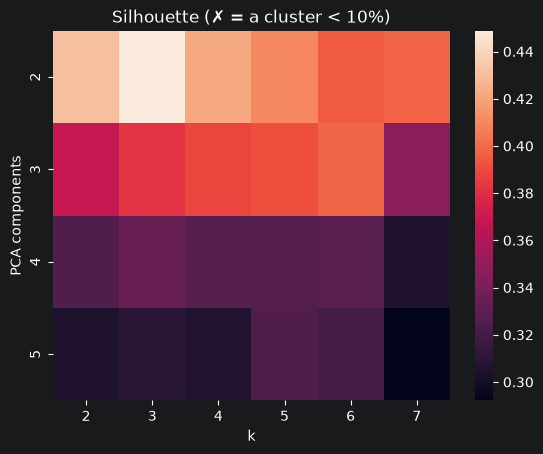

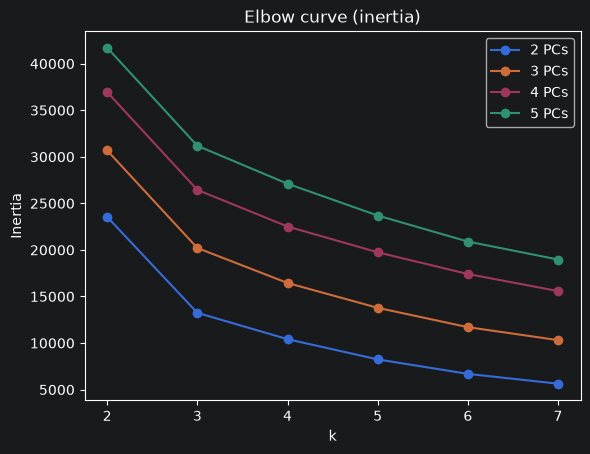

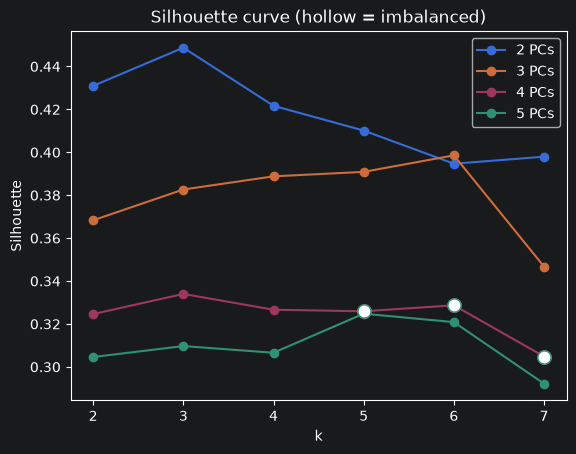

In [56]:
sil_pivot = res.pivot(index="n_components", columns="k", values="silhouette")



sns.heatmap(sil_pivot)
plt.xlabel("k")
plt.ylabel("PCA components")

plt.show()

for n, g in res.groupby("n_components"):
    plt.plot(g["k"], g["inertia"], marker="o", label=f"{n} PCs")

plt.title("Elbow curve (inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.legend()

plt.show()

for n, g in res.groupby("n_components"):
    line, = plt.plot(g["k"], g["silhouette"], marker="o", label=f"{n} PCs")
    plt.scatter(bad["k"], bad["silhouette"], s=90, facecolors="white",edgecolors=line.get_color(), zorder=3)

plt.title("Silhouette curve (hollow = imbalanced)")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.legend()

plt.show()



